# ADR Risk Prediction for DOXORUBICIN using Machine Learning

#### Objective
This notebook focuses on building a machine learning model to predict ADR risk for DOXORUBICIN using FAERS dataset.

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Models
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
df = pd.read_csv("../data/processed/doxorubicin_3000_faers.csv")
df.head()

,Drug,Reaction,Serious,Age,Sex,Report_Date
0,DOXORUBICIN,Hepatocellular injury,1,16.0,2.0,20140312
1,DOXORUBICIN,Malignant neoplasm progression,1,60.0,1.0,20140312
2,DOXORUBICIN,Septic shock,1,69.0,2.0,20140312
3,DOXORUBICIN,Hyperkalaemia,1,67.0,1.0,20140312
4,DOXORUBICIN,Leukoencephalopathy,1,69.0,2.0,20140313


In [4]:
df.info()
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Drug         3000 non-null   str    
 1   Reaction     3000 non-null   str    
 2   Serious      3000 non-null   int64  
 3   Age          1682 non-null   float64
 4   Sex          2354 non-null   float64
 5   Report_Date  3000 non-null   int64  
dtypes: float64(2), int64(2), str(2)
memory usage: 140.8 KB


,Drug,Reaction,Serious,Age,Sex,Report_Date
count,3000,3000,3000.000000,1682.000000,2354.000000,3.000000e+03
unique,1,745,NaN,NaN,NaN,NaN
top,DOXORUBICIN,Death,NaN,NaN,NaN,NaN
freq,3000,295,NaN,NaN,NaN,NaN
mean,NaN,NaN,1.019333,48.606421,1.261682,2.014103e+07
std,NaN,NaN,0.137717,22.723036,0.745237,1.619011e+03
min,NaN,NaN,1.000000,1.000000,0.000000,2.013123e+07
25%,NaN,NaN,1.000000,33.000000,1.000000,2.014060e+07
50%,NaN,NaN,1.000000,53.000000,1.000000,2.014072e+07
75%,NaN,NaN,1.000000,66.000000,2.000000,2.014101e+07


In [5]:
df.isnull().sum()

Drug              0
Reaction          0
Serious           0
Age            1318
Sex             646
Report_Date       0
dtype: int64

In [6]:
# Fill missing age
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing sex
df['Sex'] = df['Sex'].fillna('Unknown')

In [7]:
df.isnull().sum()

Drug           0
Reaction       0
Serious        0
Age            0
Sex            0
Report_Date    0
dtype: int64

In [8]:
# Create High Risk vs Low Risk based on top reactions

top_reactions = df['Reaction'].value_counts().head(10).index

df['Risk_Label'] = df['Reaction'].apply(
    lambda x: 1 if x in top_reactions else 0
)

df['Risk_Label'].value_counts()

Risk_Label
0    2045
1     955
Name: count, dtype: int64

#### Target Definition
- High Risk (1): Top frequent reactions
- Low Risk (0): Other reactions

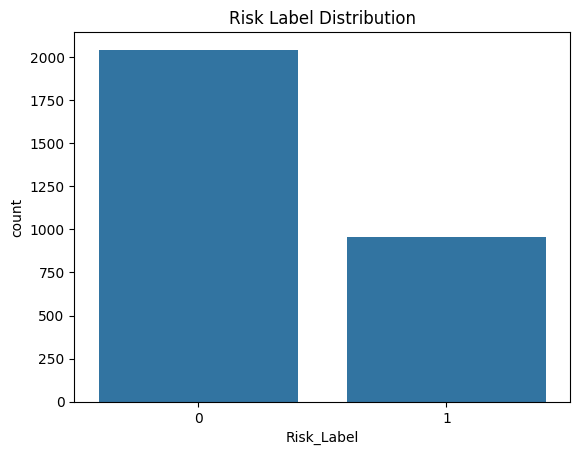

In [9]:
sns.countplot(x='Risk_Label', data=df)
plt.title("Risk Label Distribution")
plt.show()

In [11]:
# Convert Sex to string
df['Sex'] = df['Sex'].astype(str)

# Now encode
le_sex = LabelEncoder()
df['Sex'] = le_sex.fit_transform(df['Sex'])

# Drug encoding
le_drug = LabelEncoder()
df['Drug'] = le_drug.fit_transform(df['Drug'])

In [12]:
# Extract year from Report_Date
df['Year'] = df['Report_Date'].astype(str).str[:4].astype(int)

df[['Report_Date', 'Year']].head()

,Report_Date,Year
0,20140312,2014
1,20140312,2014
2,20140312,2014
3,20140312,2014
4,20140313,2014


####  Feature Engineering
Extracted year from report date to capture temporal trends in ADR reporting.

In [13]:
features = ['Age', 'Sex', 'Year']
X = df[features]
y = df['Risk_Label']

X.head()

,Age,Sex,Year
0,16.0,2,2014
1,60.0,1,2014
2,69.0,2,2014
3,67.0,1,2014
4,69.0,2,2014


##### Feature Selection
Selected features:
- Age
- Sex
- Year

Drug feature was removed due to lack of variability (single drug dataset).

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (2400, 3)
Test shape: (600, 3)


In [24]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [25]:
y_pred = model.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.755


In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.80      0.82       428
           1       0.56      0.65      0.60       172

    accuracy                           0.76       600
   macro avg       0.71      0.72      0.71       600
weighted avg       0.77      0.76      0.76       600



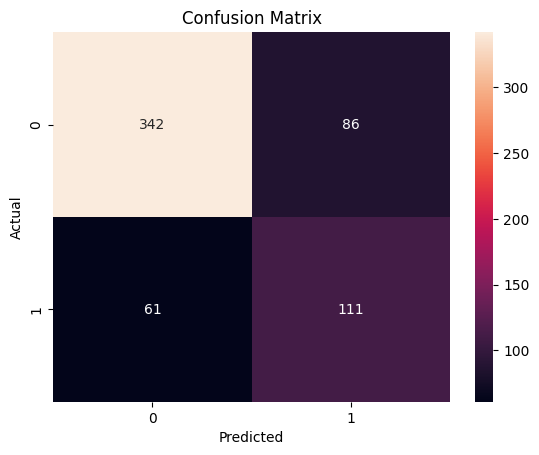

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


#### FEATURE IMPORTANCE

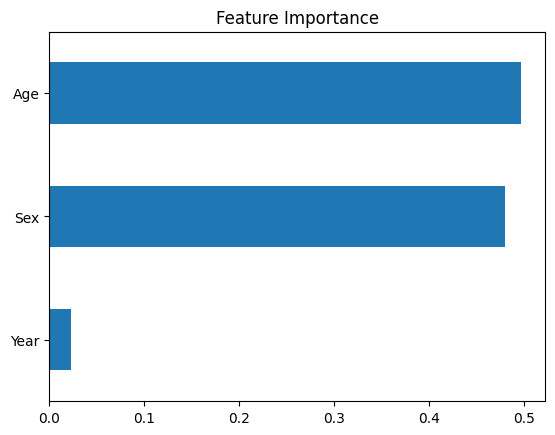

In [29]:
import pandas as pd

importances = model.feature_importances_
feature_names = features

feat_imp = pd.Series(importances, index=feature_names)
feat_imp = feat_imp.sort_values()

feat_imp.plot(kind='barh')
plt.title("Feature Importance")
plt.show()

#### PREDICTION PROBABILITY

In [30]:
y_prob = model.predict_proba(X_test)[:,1]

# Show first few probabilities
pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10],
    "Probability": y_prob[:10]
})

,Actual,Predicted,Probability
0,0,0,0.467767
1,0,0,0.376517
2,0,0,0.416074
3,1,1,0.817528
4,0,0,0.467767
5,0,0,0.283503
6,0,0,0.221428
7,0,0,0.376434
8,1,0,0.418026
9,0,0,0.208620


In [31]:
import joblib

joblib.dump(model, "adr_risk_model.pkl")

['adr_risk_model.pkl']

#### Conclusion

A machine learning model was successfully built to predict ADR risk for DOXORUBICIN.

Key Points:
- Model uses patient demographics (Age, Sex) and temporal feature (Year)
- Achieved reasonable performance despite dataset limitations

Limitations:
- Single drug dataset
- No strong PRR signals
- Limited feature diversity

Future Work:
- Multi-drug analysis
- Advanced models (XGBoost)
- SHAP explainability
- Deployment via Streamlit

In [32]:
# Example prediction
sample = pd.DataFrame({
    'Age': [60],
    'Sex': [1],
    'Year': [2014]
})

prediction = model.predict(sample)
prob = model.predict_proba(sample)

print("Prediction:", prediction)
print("Probability:", prob)

Prediction: [0]
Probability: [[0.75228264 0.24771736]]


- Initially, the model showed high accuracy but failed to detect high-risk ADR cases due to class imbalance. After applying class weighting, recall for high-risk cases improved from 34% to 65%. Although accuracy slightly decreased, the model became more reliable for healthcare applications by reducing false negatives.

In [33]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(class_weight='balanced')
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Results:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results:

              precision    recall  f1-score   support

           0       0.75      0.56      0.64       428
           1       0.33      0.53      0.40       172

    accuracy                           0.55       600
   macro avg       0.54      0.55      0.52       600
weighted avg       0.63      0.55      0.57       600



In [37]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]
roc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.7959343077591828


In [35]:
y_pred_new = (y_prob > 0.4).astype(int)

print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.93      0.53      0.68       428
           1       0.44      0.91      0.59       172

    accuracy                           0.64       600
   macro avg       0.69      0.72      0.63       600
weighted avg       0.79      0.64      0.65       600



- Initially, the model achieved higher accuracy but missed many high-risk ADR cases. By adjusting the decision threshold from 0.5 to 0.4, recall improved significantly to 91%, ensuring most high-risk cases are detected. Although this increases false positives and reduces accuracy, it is acceptable in healthcare applications where patient safety is the priority.

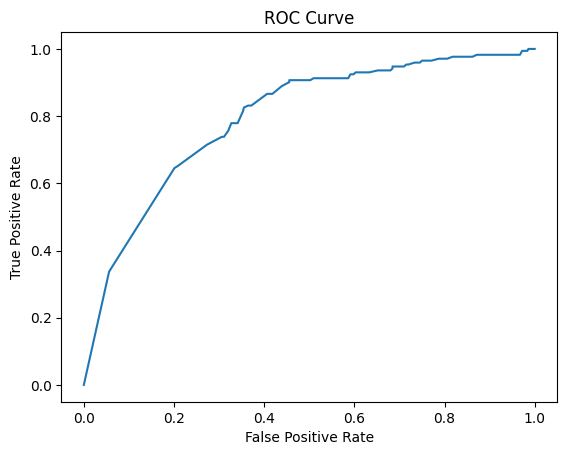

In [38]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

- The ROC curve shows good model discrimination capability, with a high true positive rate at relatively low false positive rates.”

In [40]:
import shap

## 🔍 Explainability using SHAP

SHAP (SHapley Additive exPlanations) is used to interpret machine learning predictions.

It helps us understand:
- Which features influence predictions
- How each feature contributes to ADR risk

Final SHAP shape: (600, 3)
X_test shape: (600, 3)


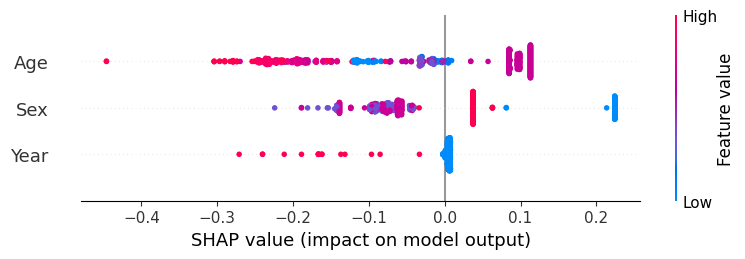

In [54]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Handle both formats
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

# 🔥 FIX: handle 3D case
if len(shap_vals.shape) == 3:
    shap_vals = shap_vals[:, :, 1]

print("Final SHAP shape:", shap_vals.shape)
print("X_test shape:", X_test.shape)

shap.summary_plot(shap_vals, X_test)

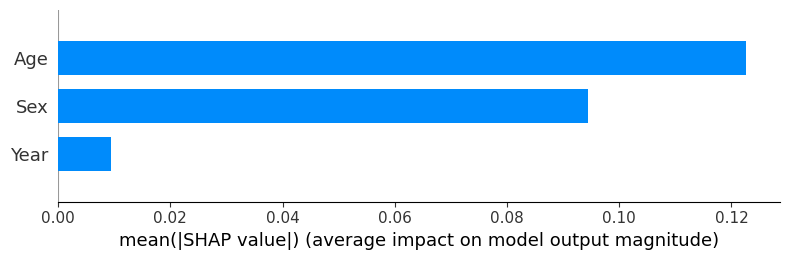

In [55]:
shap.summary_plot(shap_vals, X_test, plot_type="bar")

- Using SHAP explainability, we identified that Age is the most significant factor influencing ADR risk, followed by Sex. The Year feature had minimal impact, indicating that patient-specific characteristics are more important than temporal trends in this dataset.